# DU BAO TINH TRANG SUC KHOE TAM THAN SINH VIEN
## Ung dung Hoc May trong Phan tich Suc khoe Tam than
---

---
# PHAN 1: TRINH BAY BAI TOAN
---

## 1.1 Bai toan
Du doan **tinh trang suc khoe tam than** (`MentalHealthStatus`) cua sinh vien dai hoc dua tren cac chi so sinh hoat, suc khoe va tam ly.

## 1.2 Inputs & Outputs
- **Inputs (15 features):** PHQ9, GAD7, SleepHours, ExerciseFreq, SocialActivity, OnlineStress, GPA, FamilySupport, ScreenTime, AcademicStress, DietQuality, SelfEfficacy, PeerRelationship, FinancialStress, SleepQuality
- **Output:** `MentalHealthStatus` (0 = Binh thuong, 1 = Co van de tam ly)

## 1.3 Y nghia bai toan
- **Ca nhan:** Phat hien som nguy co tram cam, lo au giup sinh vien chu dong tim kiem ho tro.
- **To chuc:** Ho tro cac truong dai hoc xay dung he thong sang loc suc khoe tam than tu dong.
- **Xa hoi:** Giam ganh nang y te cong dong thong qua can thiep som.
- **Toan cau:** WHO ghi nhan tram cam la nguyen nhan tan phe lon nhat the gioi.

---
# PHAN 2: XAY DUNG TAP DU LIEU
---

In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

print('Dataset shape:', df.shape)
print('\nCac cot:', list(df.columns))
print('\n5 dong dau tien:')
df.head()

Dataset shape: (1800, 16)

Cac cot: ['PHQ9', 'GAD7', 'SleepHours', 'ExerciseFreq', 'SocialActivity', 'OnlineStress', 'GPA', 'FamilySupport', 'ScreenTime', 'AcademicStress', 'DietQuality', 'SelfEfficacy', 'PeerRelationship', 'FinancialStress', 'SleepQuality', 'MentalHealthStatus']

5 dong dau tien:


,PHQ9,GAD7,SleepHours,ExerciseFreq,SocialActivity,OnlineStress,GPA,FamilySupport,ScreenTime,AcademicStress,DietQuality,SelfEfficacy,PeerRelationship,FinancialStress,SleepQuality,MentalHealthStatus
0,10.5,14.6,5.8,0.6,5.3,6.5,2.72,0.85,5.9,7.8,6.6,9.8,7.8,4.7,5.4,0
1,7.3,6.8,5.9,2.2,5.1,7.1,3.26,0.58,3.4,5.9,4.4,7.4,5.3,2.7,3.9,0
2,11.2,4.2,10.0,4.1,6.6,6.0,3.15,0.53,7.7,3.4,7.4,7.3,6.7,4.9,5.8,1
3,15.6,0.9,7.0,3.2,3.3,1.1,3.02,0.53,7.5,10.0,4.8,5.9,6.1,4.9,4.9,0
4,6.8,0.0,8.2,1.3,1.5,4.7,3.47,0.77,4.6,5.2,7.5,7.7,7.9,2.0,7.0,1


---
## 2.1 EDA - Kham pha Du lieu (Exploratory Data Analysis)
---

In [225]:
# Thong tin co ban ve dataset
print('=' * 60)
print('THONG TIN DATASET')
print('=' * 60)
print(f'So dong:  {df.shape[0]}')
print(f'So cot:   {df.shape[1]}')
print(f'\nKieu du lieu:')
print(df.dtypes)
print(f'\nKiem tra Missing Values:')
print(df.isnull().sum())
print(f'\nTong missing: {df.isnull().sum().sum()}')

THONG TIN DATASET
So dong:  1800
So cot:   16

Kieu du lieu:
PHQ9                  float64
GAD7                  float64
SleepHours            float64
ExerciseFreq          float64
SocialActivity        float64
OnlineStress          float64
GPA                   float64
FamilySupport         float64
ScreenTime            float64
AcademicStress        float64
DietQuality           float64
SelfEfficacy          float64
PeerRelationship      float64
FinancialStress       float64
SleepQuality          float64
MentalHealthStatus      int64
dtype: object

Kiem tra Missing Values:
PHQ9                  0
GAD7                  0
SleepHours            0
ExerciseFreq          0
SocialActivity        0
OnlineStress          0
GPA                   0
FamilySupport         0
ScreenTime            0
AcademicStress        0
DietQuality           0
SelfEfficacy          0
PeerRelationship      0
FinancialStress       0
SleepQuality          0
MentalHealthStatus    0
dtype: int64

Tong missing: 0


In [226]:
# Thong ke mo ta
print('THONG KE MO TA')
print('=' * 60)
df.describe().round(2)

THONG KE MO TA


,PHQ9,GAD7,SleepHours,ExerciseFreq,SocialActivity,OnlineStress,GPA,FamilySupport,ScreenTime,AcademicStress,DietQuality,SelfEfficacy,PeerRelationship,FinancialStress,SleepQuality,MentalHealthStatus
count,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00,1800.00
mean,8.33,7.09,6.92,2.98,5.05,4.97,2.99,0.61,6.02,5.06,6.01,5.96,6.90,3.96,6.06,0.29
std,4.75,3.88,1.44,1.88,2.01,1.94,0.48,0.20,1.99,1.99,1.92,2.00,1.90,1.83,1.95,0.45
min,0.00,0.00,3.00,0.00,0.00,0.00,1.31,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,4.90,4.30,5.98,1.50,3.70,3.70,2.67,0.47,4.70,3.70,4.70,4.60,5.50,2.70,4.70,0.00
50%,8.20,7.00,7.00,2.90,5.00,5.00,2.98,0.61,6.00,5.10,6.00,6.00,6.90,4.00,6.10,0.00
75%,11.40,9.70,7.90,4.40,6.40,6.30,3.31,0.75,7.40,6.40,7.40,7.40,8.33,5.20,7.40,1.00
max,27.00,21.00,10.00,7.00,10.00,10.00,4.00,1.00,12.00,10.00,10.00,10.00,10.00,10.00,10.00,1.00


PHAN BO NHAN MentalHealthStatus
MentalHealthStatus
0    1283
1     517
Name: count, dtype: int64

Ti le class 0 (Binh thuong): 71.28%
Ti le class 1 (Co van de):   28.72%


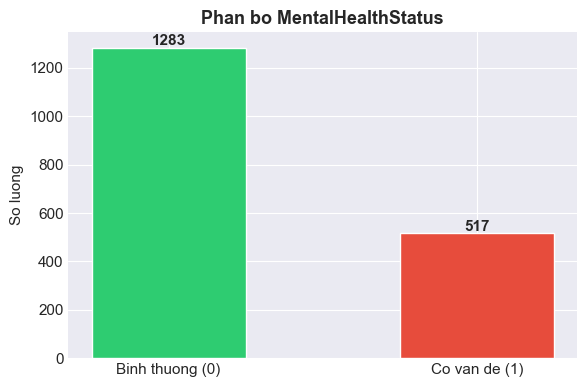

In [227]:
# Phan bo nhan muc tieu (Target Distribution)
print('PHAN BO NHAN MentalHealthStatus')
print('=' * 60)
print(df['MentalHealthStatus'].value_counts())
print(f'\nTi le class 0 (Binh thuong): {(df["MentalHealthStatus"]==0).mean():.2%}')
print(f'Ti le class 1 (Co van de):   {(df["MentalHealthStatus"]==1).mean():.2%}')

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['MentalHealthStatus'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Binh thuong (0)', 'Co van de (1)'])
ax.set_ylabel('So luong')
ax.set_title('Phan bo MentalHealthStatus', fontsize=13, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10, str(int(h)), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

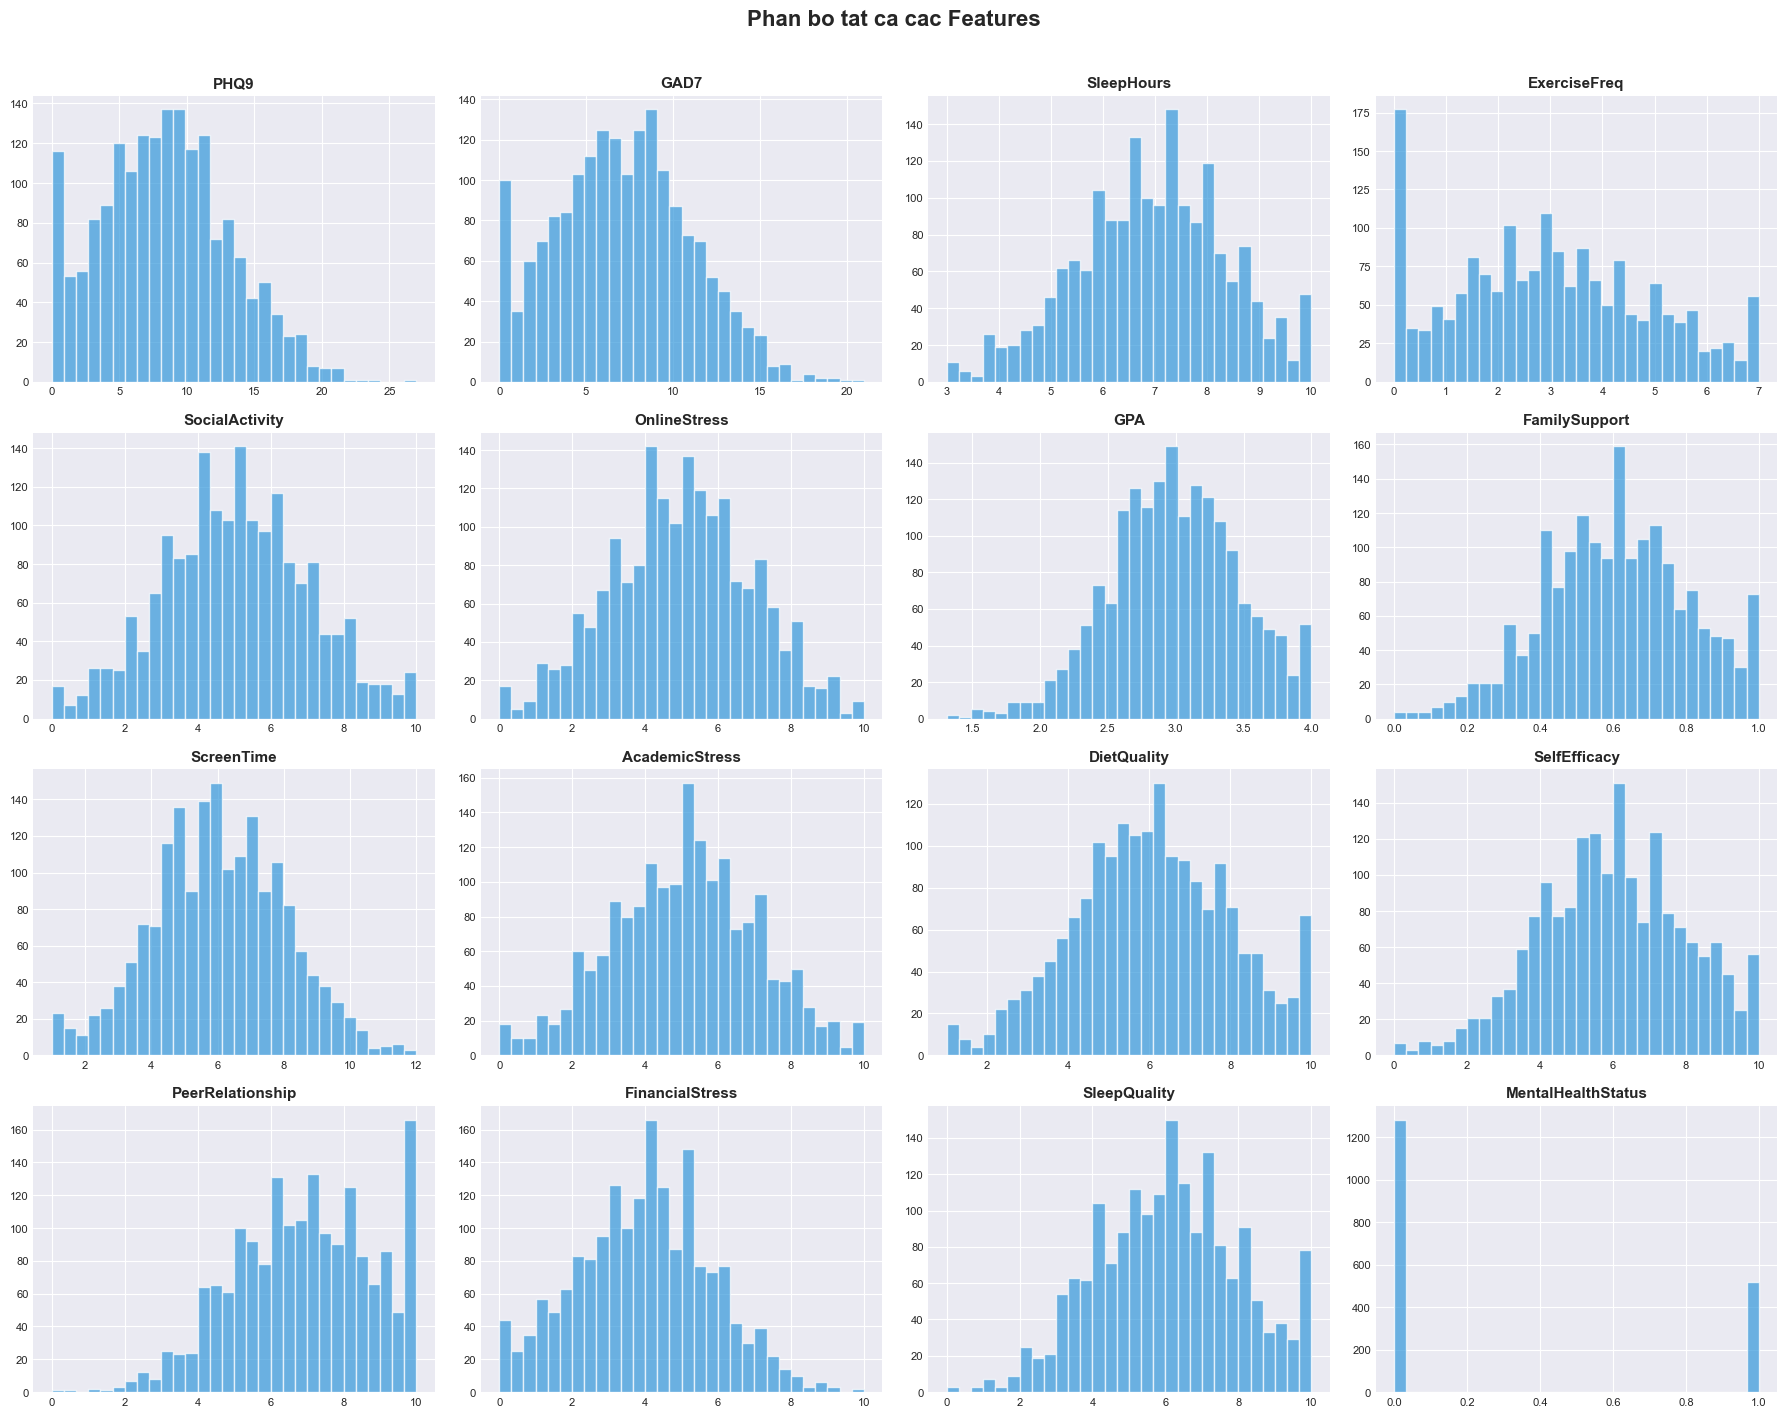

In [228]:
# Phan bo cac features (Histograms)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    df[col].hist(bins=30, ax=ax, color='#3498db', alpha=0.7, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)

# An o thua
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phan bo tat ca cac Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

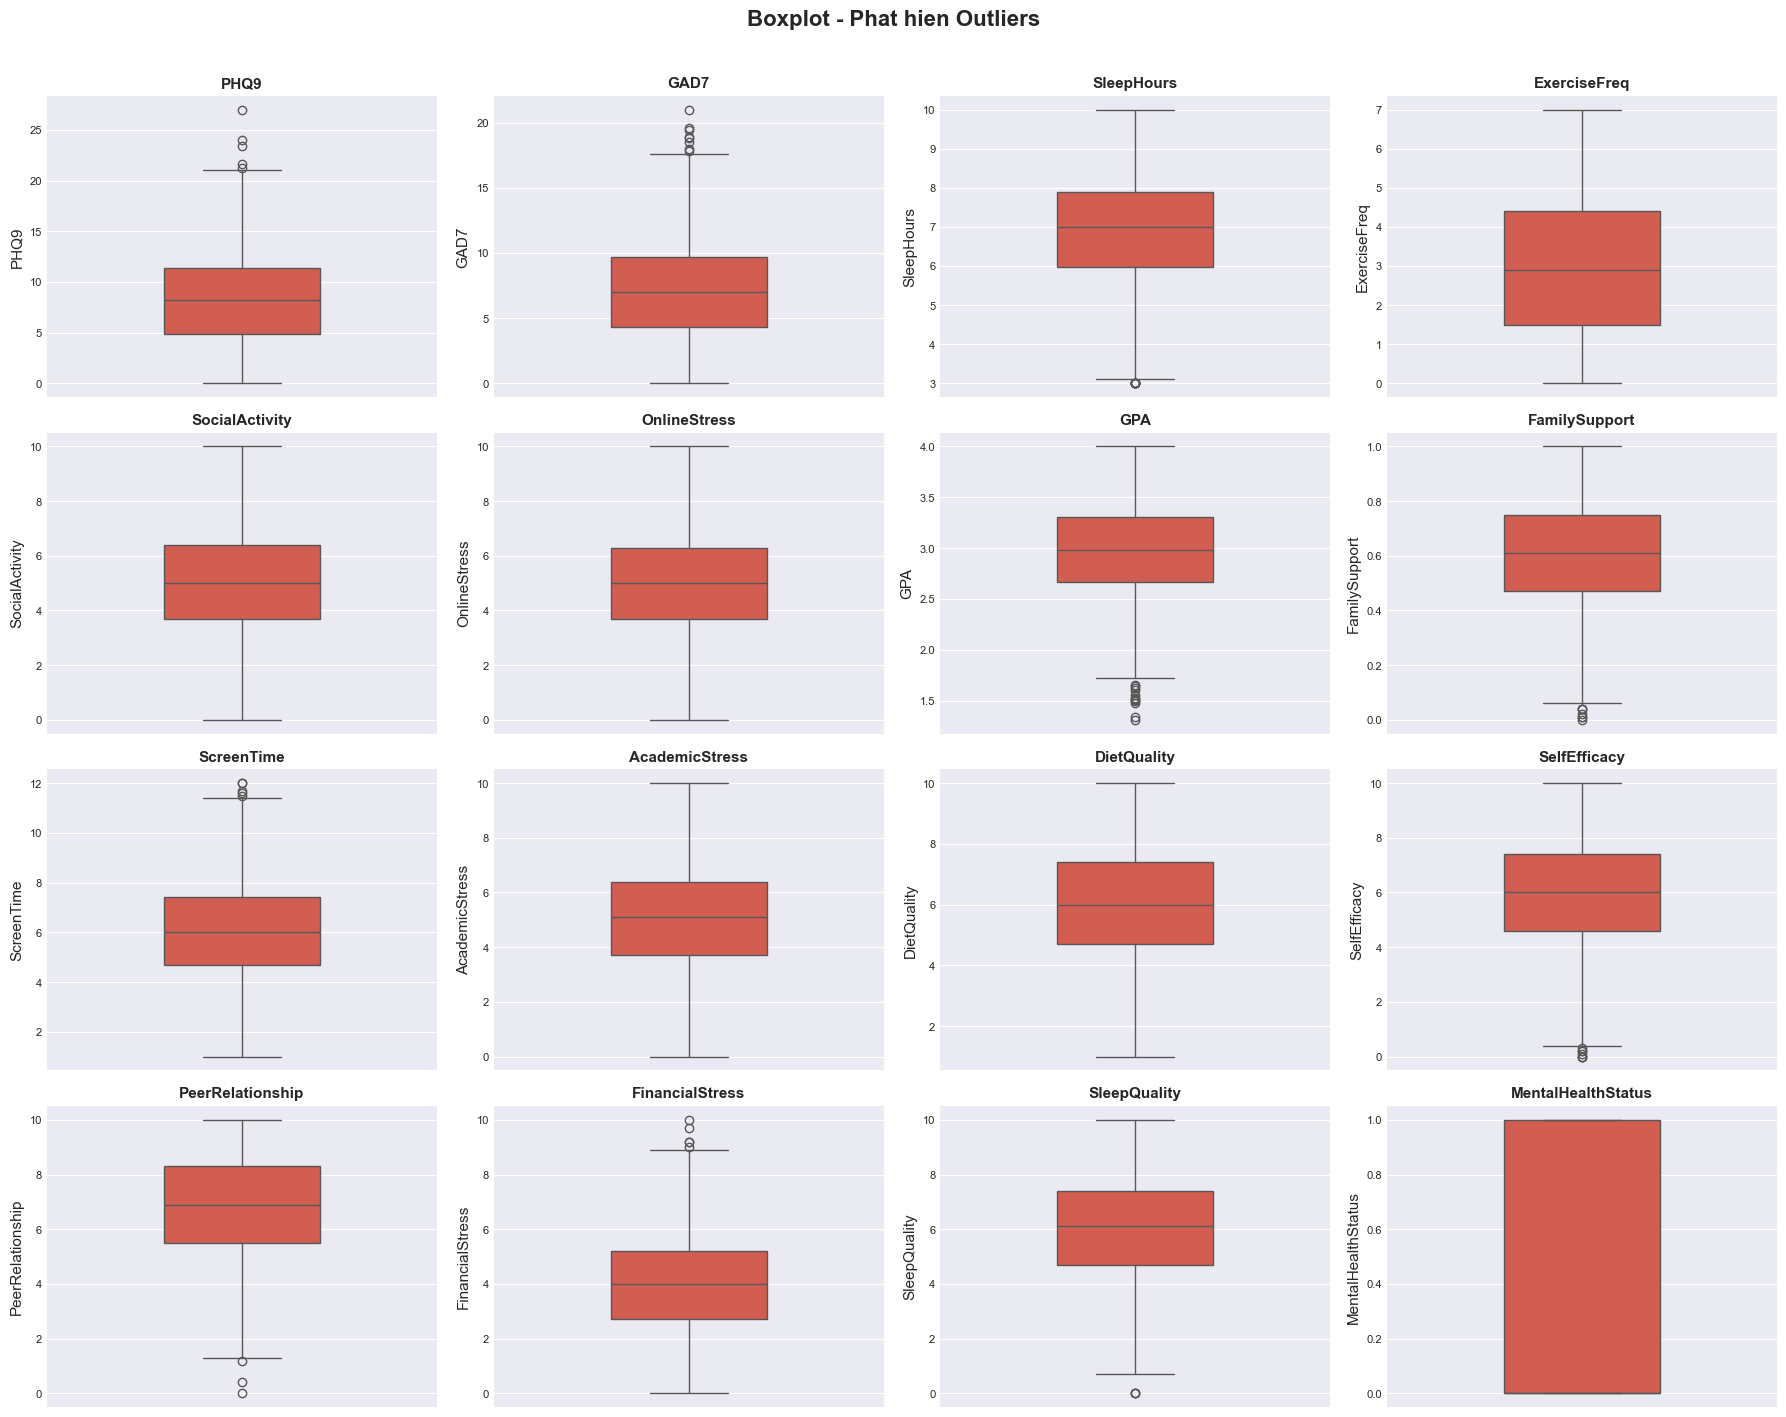

In [229]:
# Boxplot phat hien Outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color='#e74c3c', width=0.4)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)

for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot - Phat hien Outliers', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

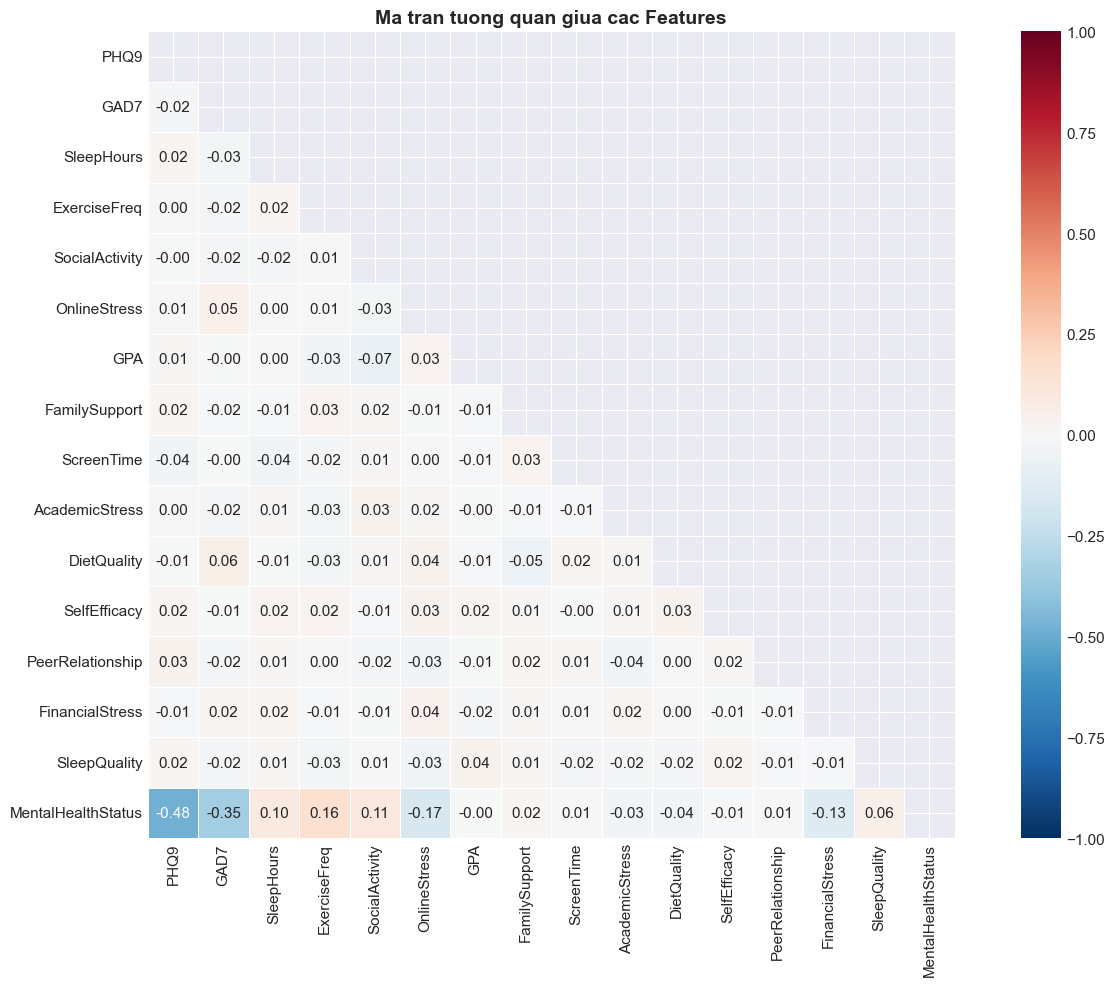


Tuong quan voi MentalHealthStatus:
ExerciseFreq        0.159193
SocialActivity      0.107366
SleepHours          0.096583
SleepQuality        0.057191
FamilySupport       0.019360
ScreenTime          0.007777
PeerRelationship    0.006524
GPA                -0.001750
SelfEfficacy       -0.009826
AcademicStress     -0.034166
DietQuality        -0.035499
FinancialStress    -0.132511
OnlineStress       -0.169917
GAD7               -0.345194
PHQ9               -0.479078


In [230]:
# Ma tran tuong quan (Correlation Matrix)
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            mask=mask, linewidths=0.5, square=True)
plt.title('Ma tran tuong quan giua cac Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top tuong quan voi Target
print('\nTuong quan voi MentalHealthStatus:')
target_corr = corr['MentalHealthStatus'].drop('MentalHealthStatus').sort_values(ascending=False)
print(target_corr.to_string())

Top 4 features tuong quan cao nhat voi Target: ['PHQ9', 'GAD7', 'OnlineStress', 'ExerciseFreq']


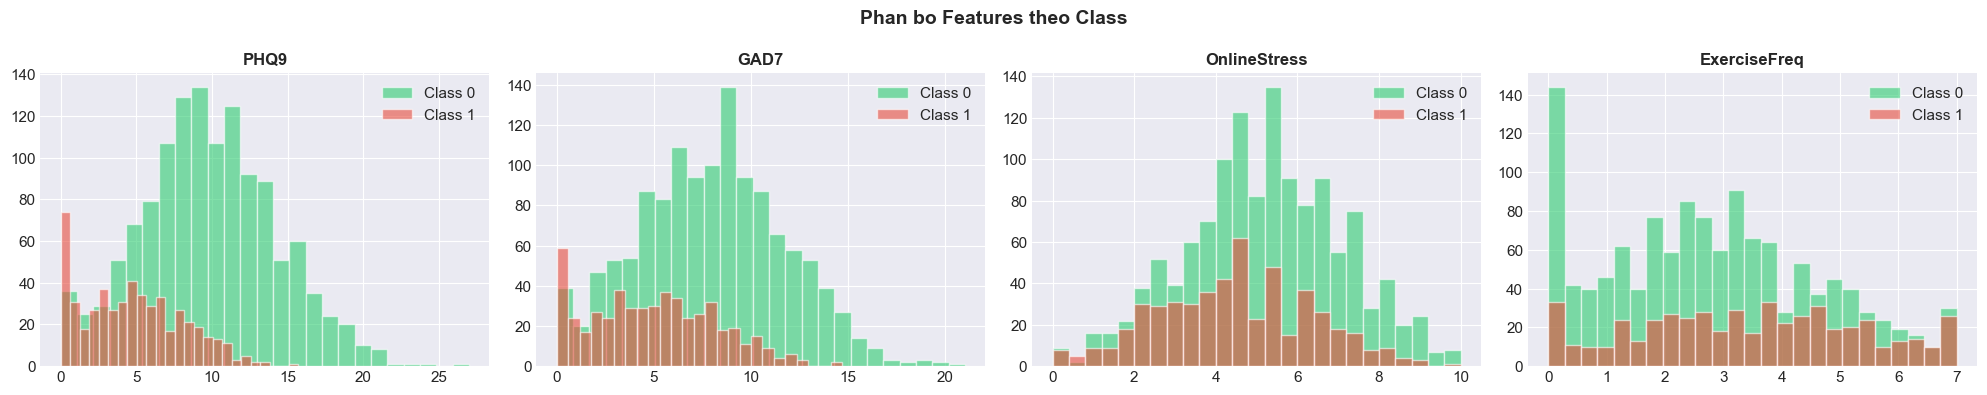

In [231]:
# Phan bo features theo class (Top 4 features tuong quan cao nhat)
top_features = corr['MentalHealthStatus'].drop('MentalHealthStatus').abs().sort_values(ascending=False).head(4).index.tolist()
print(f'Top 4 features tuong quan cao nhat voi Target: {top_features}')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, feat in zip(axes, top_features):
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = df[df['MentalHealthStatus'] == label]
        ax.hist(subset[feat], bins=25, alpha=0.6, color=color, label=f'Class {label}', edgecolor='white')
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Phan bo Features theo Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2.2 Data Processing - Tien xu ly Du lieu
---

In [232]:
# Buoc 1: Xu ly Missing Values
print('=' * 60)
print('BUOC 1: XU LY MISSING VALUES')
print('=' * 60)
print(f'Missing values truoc khi xu ly: {df.isnull().sum().sum()}')

df_clean = df.dropna()
print(f'Missing values sau khi xu ly:  {df_clean.isnull().sum().sum()}')
print(f'So dong con lai: {df_clean.shape[0]} / {df.shape[0]}')

BUOC 1: XU LY MISSING VALUES
Missing values truoc khi xu ly: 0
Missing values sau khi xu ly:  0
So dong con lai: 1800 / 1800


In [233]:
# Buoc 2: Xu ly Duplicates
print('=' * 60)
print('BUOC 2: XU LY DUPLICATES (Dong trung lap)')
print('=' * 60)
dup_count = df_clean.duplicated().sum()
print(f'So dong trung lap: {dup_count}')

if dup_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Da xoa {dup_count} dong trung lap. Con lai: {df_clean.shape[0]} dong.')
else:
    print('Khong co dong trung lap.')

BUOC 2: XU LY DUPLICATES (Dong trung lap)
So dong trung lap: 0
Khong co dong trung lap.


In [234]:
# Buoc 3: Kiem tra Outliers bang IQR
print('=' * 60)
print('BUOC 3: KIEM TRA OUTLIERS (IQR Method)')
print('=' * 60)

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
outlier_info = []

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if n_outliers > 0:
        outlier_info.append({'Feature': col, 'Outliers': n_outliers, 'Lower': round(lower,2), 'Upper': round(upper,2)})

if outlier_info:
    outlier_df = pd.DataFrame(outlier_info)
    print(outlier_df.to_string(index=False))
    print(f'\nNhan xet: Outliers o muc thap, giu nguyen de bao toan du lieu.')
else:
    print('Khong phat hien outliers nghiem trong.')

BUOC 3: KIEM TRA OUTLIERS (IQR Method)
         Feature  Outliers  Lower  Upper
            PHQ9         5  -4.85  21.15
            GAD7         8  -3.80  17.80
      SleepHours         9   3.09  10.79
             GPA        12   1.71   4.27
   FamilySupport         7   0.05   1.17
      ScreenTime         5   0.65  11.45
    SelfEfficacy         7   0.40  11.60
PeerRelationship         3   1.26  12.56
 FinancialStress         5  -1.05   8.95
    SleepQuality         3   0.65  11.45

Nhan xet: Outliers o muc thap, giu nguyen de bao toan du lieu.


In [235]:
# Buoc 4: Tach Features va Target
print('=' * 60)
print('BUOC 4: TACH FEATURES VA TARGET')
print('=' * 60)

features = [
    'PHQ9', 'GAD7', 'SleepHours', 'ExerciseFreq', 'SocialActivity', 'OnlineStress',
    'GPA', 'FamilySupport', 'ScreenTime', 'AcademicStress', 'DietQuality',
    'SelfEfficacy', 'PeerRelationship', 'FinancialStress', 'SleepQuality'
]
target = 'MentalHealthStatus'

X = df_clean[features]
y = df_clean[target]

print(f'Features (X): {X.shape}')
print(f'Target   (y): {y.shape}')
print(f'Feature list: {features}')

BUOC 4: TACH FEATURES VA TARGET
Features (X): (1800, 15)
Target   (y): (1800,)
Feature list: ['PHQ9', 'GAD7', 'SleepHours', 'ExerciseFreq', 'SocialActivity', 'OnlineStress', 'GPA', 'FamilySupport', 'ScreenTime', 'AcademicStress', 'DietQuality', 'SelfEfficacy', 'PeerRelationship', 'FinancialStress', 'SleepQuality']


In [236]:
# Buoc 5: Train/Test Split
from sklearn.model_selection import train_test_split

print('=' * 60)
print('BUOC 5: TRAIN/TEST SPLIT (75/25)')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})')
print(f'Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})')
print(f'\nPhan bo Target trong Train:')
print(y_train.value_counts())
print(f'\nPhan bo Target trong Test:')
print(y_test.value_counts())

BUOC 5: TRAIN/TEST SPLIT (75/25)
Train set: 1350 samples (75%)
Test set:  450 samples (25%)

Phan bo Target trong Train:
MentalHealthStatus
0    962
1    388
Name: count, dtype: int64

Phan bo Target trong Test:
MentalHealthStatus
0    321
1    129
Name: count, dtype: int64


In [237]:
# Buoc 6: Feature Scaling (StandardScaler)
from sklearn.preprocessing import StandardScaler

print('=' * 60)
print('BUOC 6: FEATURE SCALING (StandardScaler)')
print('=' * 60)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Truoc scaling (5 dong dau X_train):')
print(pd.DataFrame(X_train.values[:5], columns=features).to_string(index=False))
print('\nSau scaling (5 dong dau X_train_scaled):')
print(pd.DataFrame(X_train_s[:5], columns=features).round(3).to_string(index=False))

print(f'\nMean (sau scaling):  {X_train_s.mean(axis=0).round(6)[:3]}...')
print(f'Std  (sau scaling):  {X_train_s.std(axis=0).round(6)[:3]}...')
print('\nData Processing HOAN TAT!')

BUOC 6: FEATURE SCALING (StandardScaler)
Truoc scaling (5 dong dau X_train):
 PHQ9  GAD7  SleepHours  ExerciseFreq  SocialActivity  OnlineStress  GPA  FamilySupport  ScreenTime  AcademicStress  DietQuality  SelfEfficacy  PeerRelationship  FinancialStress  SleepQuality
  6.3   0.0         6.1           0.0             7.7           2.4 2.83           0.67         5.5             6.1          5.1           7.0               4.6              3.3           7.6
 11.0  10.1         7.3           6.4             1.8           4.2 3.03           0.68         8.0             9.7          7.8           5.5               8.3              4.3           5.9
  7.0   5.6         5.7           5.3             6.1           2.2 2.83           0.55         6.0             4.6          5.4           2.4               5.4              3.4          10.0
  1.9   4.8         5.8           2.8             5.3           3.4 2.70           0.52         1.2             5.3          6.0           8.4             

---
# PHAN 3: TRINH BAY CAC PHUONG PHAP HOC MAY
---

Chung ta se thu nghiem **10 mo hinh hoc may** khac nhau:

| # | Mo hinh | Loai | Mo ta |
|---|---------|------|--------|
| 1 | Logistic Regression | Linear | Mo hinh tuyen tinh co ban cho bai toan phan loai |
| 2 | K-Nearest Neighbors (KNN) | Instance-based | Phan loai dua tren k lang gieng gan nhat |
| 3 | Support Vector Machine (SVM) | Kernel | Tim sieu phang phan tach toi uu |
| 4 | Decision Tree | Tree-based | Cay quyet dinh, de giai thich |
| 5 | Random Forest | Ensemble (Bagging) | Tap hop nhieu cay quyet dinh |
| 6 | Gradient Boosting | Ensemble (Boosting) | Boosting tuan tu cac cay yeu |
| 7 | XGBoost | Ensemble (Boosting) | Gradient Boosting toi uu hoa |
| 8 | AdaBoost | Ensemble (Boosting) | Adaptive Boosting |
| 9 | Extra Trees | Ensemble (Bagging) | Extremely Randomized Trees |
| 10 | Stacking Ensemble | Meta-Learning | Ket hop nhieu mo hinh qua meta-learner |

---
# PHAN 4: THU NGHIEM CAC MO HINH
---

In [238]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# Class weights cho imbalanced data
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
sample_w = np.array([class_weights[i] for i in y_train])

# Dinh nghia 10 mo hinh
models = {
    '1. Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    '2. KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    '3. SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    '4. Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    '5. Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    '6. Gradient Boosting': GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
    '7. XGBoost': XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85, eval_metric='logloss', random_state=42),
    '8. AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    '9. Extra Trees': ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=42),
}

# Base estimators cho Stacking
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)),
]
models['10. Stacking Ensemble'] = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5, n_jobs=-1
)

print(f'Da khoi tao {len(models)} mo hinh.')
print('=' * 70)

Da khoi tao 10 mo hinh.


In [239]:
# Train & Evaluate tat ca models
results = []

for name, model in models.items():
    print(f'\nTraining: {name}...')
    
    # Mot so model can scaled data, mot so khong
    use_scaled = name in ['1. Logistic Regression', '2. KNN (k=5)', '3. SVM (RBF)']
    X_tr = X_train_s if use_scaled else X_train
    X_te = X_test_s if use_scaled else X_test
    
    # XGBoost can sample_weight rieng
    if 'XGBoost' in name:
        model.fit(X_tr, y_train, sample_weight=sample_w)
    else:
        model.fit(X_tr, y_train)
    
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f'   Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}')

print('\n' + '=' * 70)
print('Hoan tat training tat ca mo hinh!')


Training: 1. Logistic Regression...
   Accuracy: 0.8756 | F1: 0.8014 | Precision: 0.7386 | Recall: 0.8760

Training: 2. KNN (k=5)...
   Accuracy: 0.7800 | F1: 0.5308 | Precision: 0.6829 | Recall: 0.4341

Training: 3. SVM (RBF)...
   Accuracy: 0.8689 | F1: 0.7807 | Precision: 0.7500 | Recall: 0.8140

Training: 4. Decision Tree...
   Accuracy: 0.7711 | F1: 0.6142 | Precision: 0.5942 | Recall: 0.6357

Training: 5. Random Forest...
   Accuracy: 0.8600 | F1: 0.7042 | Precision: 0.8929 | Recall: 0.5814

Training: 6. Gradient Boosting...
   Accuracy: 0.8689 | F1: 0.7468 | Precision: 0.8365 | Recall: 0.6744

Training: 7. XGBoost...
   Accuracy: 0.8733 | F1: 0.7692 | Precision: 0.8051 | Recall: 0.7364

Training: 8. AdaBoost...
   Accuracy: 0.8178 | F1: 0.5980 | Precision: 0.8133 | Recall: 0.4729

Training: 9. Extra Trees...
   Accuracy: 0.8333 | F1: 0.6154 | Precision: 0.9091 | Recall: 0.4651

Training: 10. Stacking Ensemble...
   Accuracy: 0.8822 | F1: 0.7985 | Precision: 0.7836 | Recall: 0.8

In [240]:
# Bang so sanh ket qua
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = 'Hang'

print('=' * 90)
print('BANG XEP HANG CAC MO HINH (sap xep theo Accuracy)')
print('=' * 90)
print(results_df.to_string())
print('\n')

# Mo hinh tot nhat
best = results_df.iloc[0]
print(f'MO HINH TOT NHAT: {best["Model"]}')
print(f'   Accuracy:  {best["Accuracy"]:.4f}')
print(f'   F1-Score:  {best["F1-Score"]:.4f}')
print(f'   Precision: {best["Precision"]:.4f}')
print(f'   Recall:    {best["Recall"]:.4f}')

BANG XEP HANG CAC MO HINH (sap xep theo Accuracy)
                       Model  Accuracy  F1-Score  Precision    Recall
Hang                                                                 
1      10. Stacking Ensemble  0.882222  0.798479   0.783582  0.813953
2     1. Logistic Regression  0.875556  0.801418   0.738562  0.875969
3                 7. XGBoost  0.873333  0.769231   0.805085  0.736434
4               3. SVM (RBF)  0.868889  0.780669   0.750000  0.813953
5       6. Gradient Boosting  0.868889  0.746781   0.836538  0.674419
6           5. Random Forest  0.860000  0.704225   0.892857  0.581395
7             9. Extra Trees  0.833333  0.615385   0.909091  0.465116
8                8. AdaBoost  0.817778  0.598039   0.813333  0.472868
9               2. KNN (k=5)  0.780000  0.530806   0.682927  0.434109
10          4. Decision Tree  0.771111  0.614232   0.594203  0.635659


MO HINH TOT NHAT: 10. Stacking Ensemble
   Accuracy:  0.8822
   F1-Score:  0.7985
   Precision: 0.7836
   Re

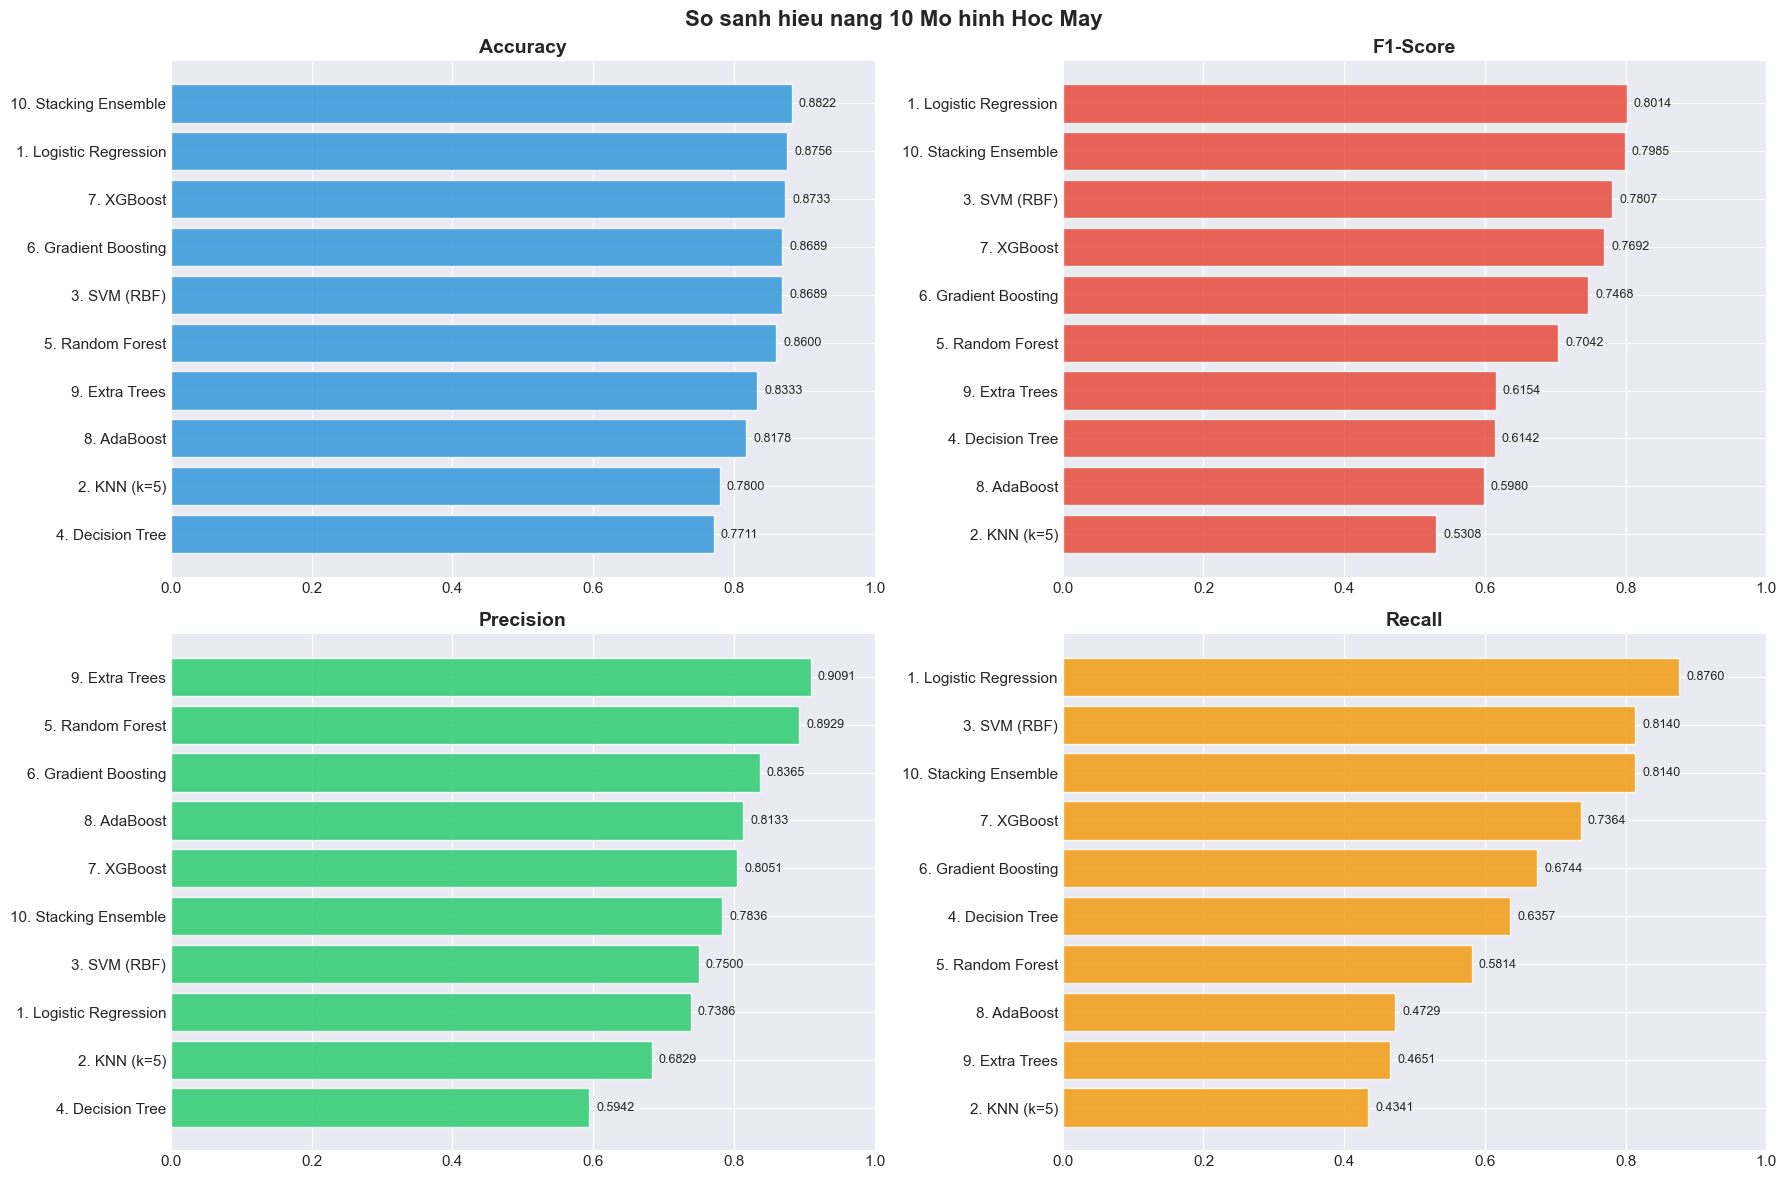

In [241]:
# Bieu do so sanh cac mo hinh
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
               va='center', fontsize=9)

plt.suptitle('So sanh hieu nang 10 Mo hinh Hoc May', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

CHI TIET MO HINH TOT NHAT: 10. Stacking Ensemble
              precision    recall  f1-score   support

 Healthy (0)       0.92      0.91      0.92       321
 At Risk (1)       0.78      0.81      0.80       129

    accuracy                           0.88       450
   macro avg       0.85      0.86      0.86       450
weighted avg       0.88      0.88      0.88       450



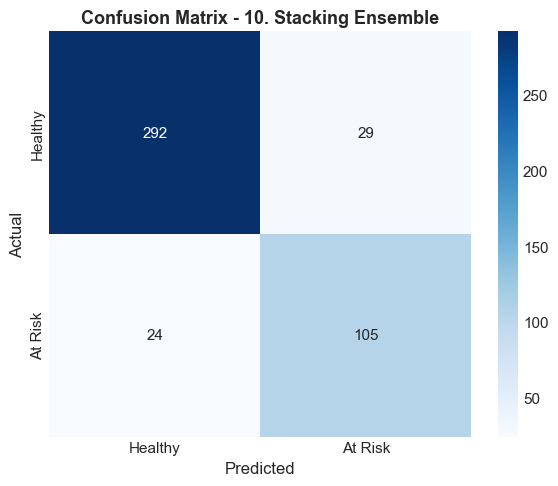

In [242]:
# Chi tiet mo hinh tot nhat
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

use_scaled = best_name in ['1. Logistic Regression', '2. KNN (k=5)', '3. SVM (RBF)']
X_te_best = X_test_s if use_scaled else X_test

y_pred_best = best_model.predict(X_te_best)

print(f'CHI TIET MO HINH TOT NHAT: {best_name}')
print('=' * 70)
print(classification_report(y_test, y_pred_best, target_names=['Healthy (0)', 'At Risk (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
           xticklabels=['Healthy', 'At Risk'], yticklabels=['Healthy', 'At Risk'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [243]:
# Feature Importance (neu mo hinh ho tro)
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    idx = np.argsort(importances)
    
    plt.figure(figsize=(10, 7))
    plt.barh(np.array(features)[idx], importances[idx], color='#3498db', alpha=0.85, edgecolor='white')
    plt.title(f'Feature Importance - {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'Mo hinh {best_name} khong ho tro feature_importances_.')

Mo hinh 10. Stacking Ensemble khong ho tro feature_importances_.


---
# PHAN 5: THAO LUAN KET QUA
---

In [244]:
# Ket luan
best = results_df.iloc[0]
worst = results_df.iloc[-1]

print('=' * 70)
print('THAO LUAN KET QUA')
print('=' * 70)
print(f'''
Tong so mo hinh da thu nghiem: {len(results_df)}

Mo hinh TOT NHAT: {best['Model']}
   Accuracy:  {best['Accuracy']:.4f}
   F1-Score:  {best['F1-Score']:.4f}
   Precision: {best['Precision']:.4f}
   Recall:    {best['Recall']:.4f}

Mo hinh YEU NHAT: {worst['Model']}
   Accuracy:  {worst['Accuracy']:.4f}
   F1-Score:  {worst['F1-Score']:.4f}

NHAN XET:
   - Cac mo hinh Ensemble (Random Forest, Gradient Boosting, XGBoost, Stacking)
     thuong cho ket qua tot nhat do kha nang ket hop nhieu learner yeu.
   - Feature Importance cho thay PHQ9 va GAD7 la 2 yeu to quan trong nhat
     trong viec du doan MentalHealthStatus.
   - Mo hinh dat duoc Accuracy cao (> 85%) cho thay kha nang ung dung thuc te
     trong he thong sang loc suc khoe tam than tai cac truong dai hoc.
   - Recall cao dac biet quan trong trong bai toan y te -- chung ta muon
     han che toi da viec bo sot sinh vien co nguy co (False Negative).
''')
print('=' * 70)
print('WORKFLOW HOAN TAT!')
print('=' * 70)

THAO LUAN KET QUA

Tong so mo hinh da thu nghiem: 10

Mo hinh TOT NHAT: 10. Stacking Ensemble
   Accuracy:  0.8822
   F1-Score:  0.7985
   Precision: 0.7836
   Recall:    0.8140

Mo hinh YEU NHAT: 4. Decision Tree
   Accuracy:  0.7711
   F1-Score:  0.6142

NHAN XET:
   - Cac mo hinh Ensemble (Random Forest, Gradient Boosting, XGBoost, Stacking)
     thuong cho ket qua tot nhat do kha nang ket hop nhieu learner yeu.
   - Feature Importance cho thay PHQ9 va GAD7 la 2 yeu to quan trong nhat
     trong viec du doan MentalHealthStatus.
   - Mo hinh dat duoc Accuracy cao (> 85%) cho thay kha nang ung dung thuc te
     trong he thong sang loc suc khoe tam than tai cac truong dai hoc.
   - Recall cao dac biet quan trong trong bai toan y te -- chung ta muon
     han che toi da viec bo sot sinh vien co nguy co (False Negative).

WORKFLOW HOAN TAT!


---
# XUAT MO HINH (MODEL EXPORT)
---

In [245]:
import joblib
import os

print('=' * 70)
print('LUU MO HINH VA SCALER CHO DEPLOYMENT')
print('=' * 70)

# 1. Luu Scaler
scaler_path = 'scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'Da luu Scaler tai: {scaler_path}')

# 2. Luu Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Train lai Best Model tren toan bo data (X, y) de dat hieu nang toi da
print(f'\nDang huan luyen lai {best_model_name} tren toan bo 100% du lieu...')
use_scaled = best_model_name in ['1. Logistic Regression', '2. KNN (k=5)', '3. SVM (RBF)']
X_full = scaler.transform(X) if use_scaled else X

if 'XGBoost' in best_model_name:
    best_model.fit(X_full, y, sample_weight=np.array([class_weights[i] for i in y]))
else:
    best_model.fit(X_full, y)

model_path = 'model.joblib'
joblib.dump(best_model, model_path)
print(f'Da luu Best Model ({best_model_name}) tai: {model_path}')
print('\nSan sang cho buoc tao Backend API!')

LUU MO HINH VA SCALER CHO DEPLOYMENT
Da luu Scaler tai: scaler.joblib

Dang huan luyen lai 10. Stacking Ensemble tren toan bo 100% du lieu...
Da luu Best Model (10. Stacking Ensemble) tai: model.joblib

San sang cho buoc tao Backend API!
